<a href="https://colab.research.google.com/github/paninishah/deepdream/blob/main/deepdream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import tensorflow as tf
#toolkit for neural networks, computes gradients automatically (automatic differentiation)
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import inception_v3
from tensorflow.keras.preprocessing import image

In [30]:
model = inception_v3.InceptionV3(
    weights="imagenet",
    include_top=False
)
#load model with weights from imagenet
#weights store statistical patterns that were useful for solving the task
#deepdream visualises the information hidden in the weights

In [31]:
model.summary()
#conv = actual feature detectors
#batch normalization = keeps activations in a healthy range
#activation = applies functions to introduce nonlinearity
#max pooling = keeps most imp info, shrinks feature maps
#avg pooling = takes avg instead of max^

#feature map = how strongly a feature maps at each location
#image size isnt defined cause i said include top = false, so i can pass any image size later

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_376 (Conv2D) │ (None, None,      │        864 │ input_layer_4[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_376[0][0]  │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_376      │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_377 (Conv2D) │ (None, None,      │      9,216 │ activation_376[0… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_377[0][0]  │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_377      │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_378 (Conv2D) │ (None, None,      │     18,432 │ activation_377[0… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_378[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_378      │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, None,      │          0 │ activation_378[0… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_379 (Conv2D) │ (None, None,      │      5,120 │ max_pooling2d_16… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_379[0][0]  │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_379      │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_380 (Conv2D) │ (None, None,      │    138,240 │ activation_379[0… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_380[0][0]  │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_380      │ (None, None,      │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

deepdream basically asks : if this neuron outputs 9.8, how can i change the image so it outputs 15?

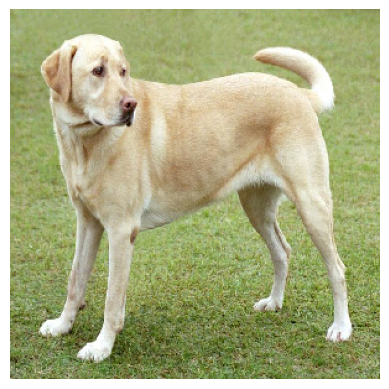

In [32]:
import requests

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

img_path = tf.keras.utils.get_file("dog.jpg", url)

img = image.load_img(img_path, target_size=(299, 299))

plt.imshow(img)
plt.axis("off")
plt.show()

In [45]:
layer_name = "mixed7"

dream_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer(layer_name).output
)

print(dream_model.output_shape)

(None, None, None, 768)


In [46]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = inception_v3.preprocess_input(img_array)

activations = dream_model(img_array)

print(activations.shape)

(1, 17, 17, 768)


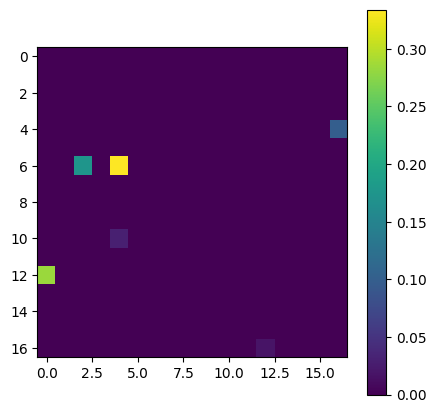

In [50]:
#visualising one of the 256 feature maps
feature_map = activations[0, :, :, 767]

plt.figure(figsize=(5,5))
plt.imshow(feature_map, cmap="viridis")
plt.colorbar()
plt.show()

#this shows feature detector 0's response. bright = high activation
#vaguely looks like the dog!

#for 7, looks like it's brightening up for eyes

deepdream aims to maximize activation, so we use gradient ascent:
weights are fixed from training, so the image changes

gradient descent minimizes a function by repeatedly moving in the direction of steepest decrease, whereas gradient ascent maximizes a function by moving in the direction of steepest increase. neural network training uses gradient descent to reduce prediction error, while deepdream uses gradient ascent to amplify internal activations and reveal learned features.

deepdream maximixes the activations of all features in a layer at once, that's why images end up looking so weird

In [51]:
#define the dream objective
loss = tf.reduce_mean(activations)

print("Loss:", loss.numpy())

Loss: 0.050080266


In [52]:
img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)

    activations = dream_model(img_tensor)

    loss = tf.reduce_mean(activations)

gradients = tape.gradient(loss, img_tensor)

print("Gradient shape:", gradients.shape)

#tape watches the image, because for deepdream we want gradients with respect to the image
#here loss doesnt really mean loss, its more like a dream score. we want to maximize it.

Gradient shape: (1, 299, 299, 3)


deepdream defines an objective function representing the activation of selected neurons or layers. unlike neural network training, which minimizes prediction error, deepdream maximizes this objective through gradient ascent, causing the input image to evolve toward patterns that strongly excite the network.

In [53]:
step_size = 0.01

img_tensor = img_tensor + step_size * gradients
#optimization works best with small steps


In [54]:
new_activations = dream_model(img_tensor)

new_loss = tf.reduce_mean(new_activations)

print("Old loss:", loss.numpy())
print("New loss:", new_loss.numpy())

Old loss: 0.050080266
New loss: 0.050082393


so gradient ascent works!!

deepdream repeatedly computes the gradient of a chosen objective with respect to the input image and updates the image in the direction that increases the objective.

the deepdream algorithm is basically:

Repeat:

1. Measure how excited the layer is.

2. Determine which pixel changes
   would increase that excitement.

3. Make those changes.

4. Repeat.

In [55]:
#full dream loop
def dream_step(img, steps=100, step_size=0.01):

    for step in range(steps):

        with tf.GradientTape() as tape:
            tape.watch(img)

            activations = dream_model(img)

            loss = tf.reduce_mean(activations)

        gradients = tape.gradient(loss, img)

        gradients /= tf.math.reduce_std(gradients) + 1e-8
        #normalize gradients

        img = img + step_size * gradients
        #^gradient ascent step

    return img

In [56]:
dreamed_img = dream_step(
    img_tensor,
    steps=100,
    step_size=0.01
)

In [57]:
final_activations = dream_model(dreamed_img)

final_loss = tf.reduce_mean(final_activations)

print("Original Loss:", loss.numpy())
print("Final Loss:", final_loss.numpy())

Original Loss: 0.050080266
Final Loss: 0.44789034


yay it increased (?)significantly(?)

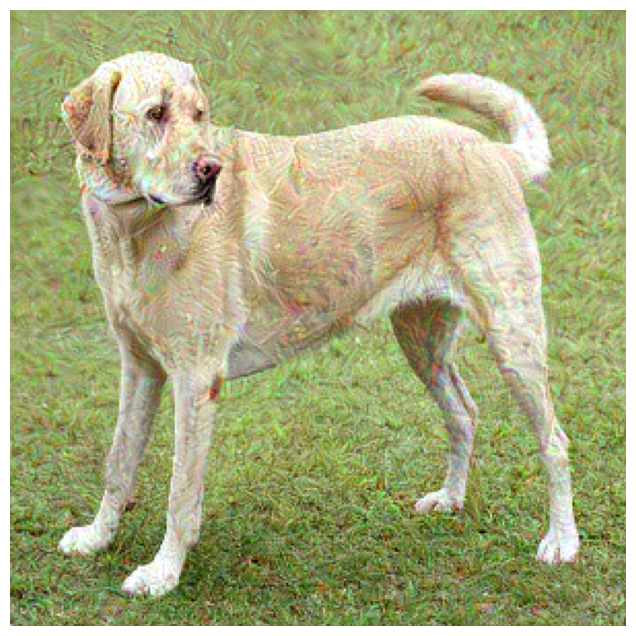

In [58]:
dream_img = dreamed_img.numpy()[0]

dream_img = (dream_img + 1.0) * 127.5

dream_img = np.clip(dream_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(8,8))
plt.imshow(dream_img)
plt.axis("off")
plt.show()

mixed0 is a shallow layer that focuses on textures and lines. that's why the image still looks relatively the same.

deepdream is basically adding **more texture** instead of **more dog**.

mixed7 is a layer that i thought was recognizing eyes? but looks like it didnt change much

although mixed7 exhibited a significantly larger relative increase in activation (8.94× versus 3.15× for mixed0), the resulting image appeared visually less distorted. this demonstrates that the magnitude of activation growth does not necessarily correlate with perceived visual change.